# Aufgabenstellung
1. Bauen Sie eine Reihenschaltung bestehend aus drei Widerständen mit unterschiedlichen Widerstandswerten auf. Legen Sie eine Spannung geeigneter Größe an. Messen Sie Spannungen und Ströme. Vergleichen Sie mit Ihren Vorhersagen. Wiederholen Sie die Messungen an einer Parallelschaltung bestehend aus drei Widerständen.
2. Bauen Sie einen Spannungsteiler auf und messen Sie die Spannung über den zweiten Widerstand für unterschiedliche Lastwiderstände. Stellen Sie die Daten graphisch dar und vergleichen Sie mit Ihren Vorhersagen.
3. Bauen Sie eine Wheatstone-Brücke auf. Legen Sie eine Spannung geeigneter Größe an. Messen Sie die Brückenspannung als Funktion des Widerstandswerts eines variablen Widerstands in einem Brückenarm. Stellen Sie die Daten graphisch dar und vergleichen Sie mit Ihren Vorhersagen.
4. Bauen Sie einen Hoch- oder Tiefpass auf. Messen Sie mit einem Oszilloskop die Transferfunktion als Funktion der Frequenz. Stellen Sie die Daten graphisch dar und vergleichen Sie mit Ihren Vorhersagen.

# Aufgabe 1
In Aufgabe 1 wurden zwei Schaltungen aufgebaut: eine Reihenschaltung und eine Parallelschaltung von Widerständen. Die Spannungen und Ströme wurden gemessen und mit den Vorhersagen verglichen. Für die beide Schaltungen wurde eine gleichstrom Spannung von 5V angelegt. Für die Wiederstände wurden die Werte 100$\Omega$. 200$\Omega$ und 997$\Omega$ gewählt.

## Theoretische Grundlagen
Da wie in Aufgabe eins sehr einfache Schaltungen haben werden nur die Grundlagen der Kirchhoff'schen Regeln und die Ohm'sche Gesetz benötigt.
Es gibt zwei Kirchhoff'sche Regeln. die Knotenregel und die Maschenregel die dem Ernergieerhaltungssatz folgen. Die Knotenregel besagt das die Summer der Strome gleich 0 ist. Es geht also in einer idalen Masche kein Strom verloren noch wird Strom kreiert.
$$\sum_i{I_i}=0$${#eq-kirchhoffsches-gesetzt1}
Während die Maschenregel besagt das die Summe der Spannungen in einer Masche gleich 0 ist.
$$\sum_i{U_i}=0$${#eq-kirchhoffsches-gesetzt2}
Das Ohm'sche Gesetz beschreibt den Zusammenhang zwischen Spannung. Strom und Widerstand.
$$U=R I$${#eq-ohmgesetz}


## Reihenschaltung
Im experiment wurde wie in folgender Abbildung aufgebaut. Dabei wurde der Wiederstand, für die drei Widerstände notiert und die Spannung über jeden einzelnen Wiederstand gemessen. Zusätzlich wurde die Eingagnsspannung $U_E$ über ein weiters digital Multimeter abgelesen. Auch der Strom wurde Stichprobenweise gemessen.
![Reihenschaltung im Experiment](./Bilder/Reihenschaltung.png)

Folgende Daten wurden gemessen:

| Widerstand ($\Omega$) | Spannung über Wiederstand $U_W$ (V) | Strom $I$ (mA) | Eingangsspannung $U_E$ (V) | 
|-----------------------|------------------------|------------|----------------------|
| 997                   | 3.77                    | -          | 4.98                    |
| 200                   | 0.75                    | $R_1$ über $R_2$: 3.75          | 4.99                    |
| 100                   | 0.38                    | $R_2$ über $R_3$: 3.76          | 4.99                    |
: Tabelle der Messwerte der Reihenschaltung

Bei der Auswertung der Daten wie man in [Abbildung @fig-reihe] sehen kann, kommt man beim Curve Fit auf $\approx3.78A$ was in der Nähe des gemessenen Wertes des Stroms von 3.75A bzw. 3.76A ist. Mittels des ohmsche Gesetzt $U=R I$ kommt man auf eine durchschnittliche Stromstärke $I \approx 3.77mA$. 

Ermittelte Stromstärke I für Reihenschaltung: 0.003783074838945133 A
Standardabweichung der Steigung: 8.4941e-06 A


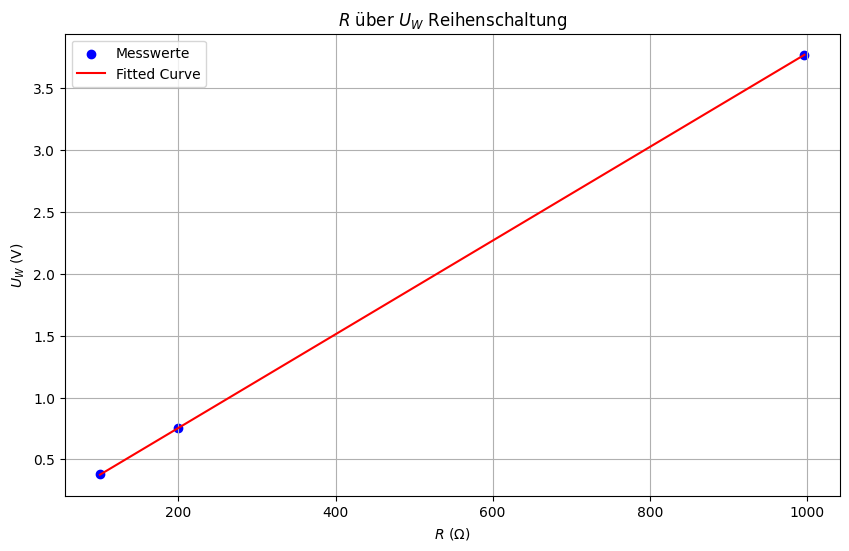

In [57]:
#| label: fig-reihe
#| fig-cap: R über U mit linearem Fit für Reihneschaltung
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load csv data
data = pd.read_csv('./Daten/Daten_Aufgabe_1_Reihe.csv')

wiederstand = data['R[Ohm]'].values
U_W = data['U_W[V]'].values

#curve-fit
def fit_func(x, a, b):
    return a * x + b
from scipy.optimize import curve_fit
params, covariance = curve_fit(fit_func, wiederstand, U_W)

print("Ermittelte Stromstärke I für Reihenschaltung:", params[0], "A")
print(f"Standardabweichung der Steigung: {np.sqrt(np.diag(covariance))[0]:.4e} A")

# Plotting the data and the fitted curve
plt.figure(figsize=(10, 6))
plt.scatter(wiederstand, U_W, label='Messwerte', color='blue')
plt.plot(wiederstand, fit_func(wiederstand, *params), label='Fitted Curve', color='red')
plt.xlabel('$R$ ($\Omega$)')
plt.ylabel('$U_W$ (V)')
plt.title('$R$ über $U_W$ Reihenschaltung')
plt.legend()
plt.grid()
plt.show()

## Parallelschaltung
Im Experiment wurde eine Parallelschaltung aufgebaut, wie in der folgenden Abbildung dargestellt. Dabei wurden drei Widerstände parallel geschaltet und jeweils die Spannung über jedem Widerstand sowie der Strom durch jeden einzelnen Widerstand gemessen. Zusätzlich wurde die Eingangsspannung $U_E$ mithilfe eines digitalen Multimeters erfasst.

![Parallelschaltung im Experiment](./Bilder/Parallelschaltung.png)

Folgende Daten wurden gemessen:

| Widerstand $R$ ($\Omega$) | Gemessene Spannung $U_W$ (V) | Eingangsspannung $U_E$ (V) | Strom $I$ (mA) |
|----------------------------|-------------------------------|-----------------------------|----------------|
| 997                        | 4.27                          | 4.97                        | 4.35           |
| 200                        | 4.19                          | 4.97                        | 20.3           |
| 100                        | 4.22                          | 4.97                        | 39.5           |
: Tabelle der Messwerte für die Parallelschaltung

Wie aus den Messwerten ersichtlich ist, ist die Spannung über allen Widerständen in einer Parallelschaltung nahezu gleich groß und entspricht in guter Näherung der Eingangsspannung $U_E$. Dies entspricht der Theorie, nach der in einer Parallelschaltung gilt $ U_W = U_E $.

Der Strom durch die einzelnen Widerstände unterscheidet sich je nach ihrem Widerstandswert gemäß dem Ohm’schen Gesetz. So ist folglich, dass kleinere Widerstände einen größeren Strom durchlassen, was in den Messwerten gut erkennbar ist. Der 100 $\Omega$-Widerstand führt den größten Strom, während durch den 997 $\Omega$-Widerstand der geringste Strom fließt.

Wie in [Abbildung @fig-parallel] kommen wir beim Curve Fit auf eine Spannung von $3.90V$ was in der Nähe des durchschnittlich gemessen Wertes von $4.22V$ ist.



Ermittelte Steigung (Spannung): 3.90 V
Standardabweichung der Steigung: 8.4941e-06 V


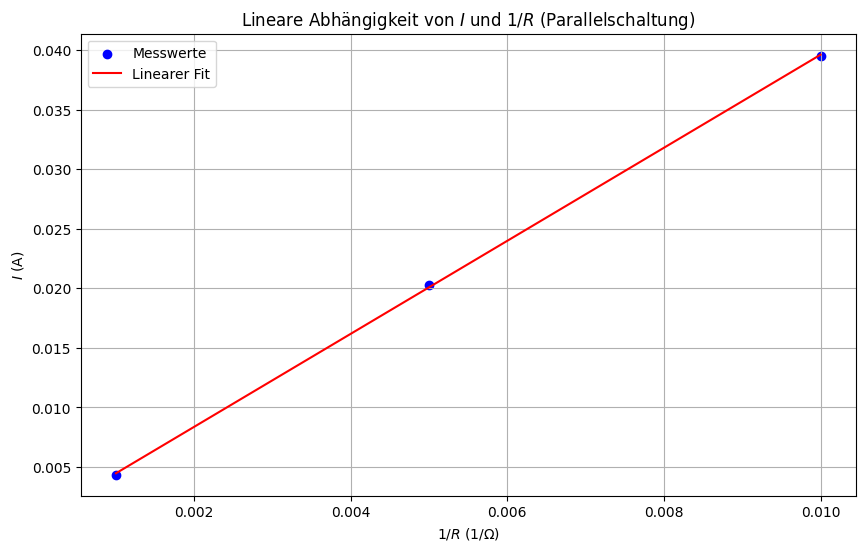

In [56]:
#| label: fig-parallel
#| fig-cap: 1/R über I mit linearem Fit für Parallelschaltung
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# CSV laden
data = pd.read_csv('./Daten/Daten_Aufgabe_1_Parallel.csv')

R = data['R[Ohm]'].values
I_mA = np.array([4.35, 20.3, 39.5])
I_A = I_mA / 1000  # in A
inv_R = 1 / R      # Leitwert in 1/Ohm

# Fit-Funktion: I = a * (1/R) + b
def fit_func(x, a, b):
    return a * x + b

params, _ = curve_fit(fit_func, inv_R, I_A)

# Fit-Parameter
a, b = params
print(f"Ermittelte Steigung (Spannung): {a:.2f} V")
# Standartabweichung
print(f"Standardabweichung der Steigung: {np.sqrt(np.diag(covariance))[0]:.4e} V")
#print(f"y-Achsenabschnitt (Offset): {b:.4e} A")

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(inv_R, I_A, label='Messwerte', color='blue')
plt.plot(inv_R, fit_func(inv_R, *params), label='Linearer Fit', color='red')
plt.xlabel('$1/R$ ($1/\\Omega$)')
plt.ylabel('$I$ (A)')
plt.title('Lineare Abhängigkeit von $I$ und $1/R$ (Parallelschaltung)')
plt.legend()
plt.grid()
plt.show()



## Fehlerbetrachtung
### Reihenschaltung
Bei der Reihenschaltung wurde die Stromstärke experimentell mittels linearem Fit der Spannungsdaten zu den Widerständen ermittelt.
Dabei betrug die Standardabweichung der Steigung $ \sigma = 8.49 \cdot 10^{-6} \,\text{A} $
Laut der Tabbelle des Multimeters beträgt die Genauigkeit im Spannungsmessbereich:

$$\pm (0.8\% + 3\,\text{Digit}) \text{ bei 20 V}$${#eq-343}

Bei einer gemessenen Spannung von 3.78 mA ergibt sich ein Messfehler von:

$$\Delta U = 0.8\% \cdot 3.78\,\text{mA} + 0.005\,\text{mA} = 0.03524\,\text{mA}$${#eq-342}

### Parallelschaltung

Bei der Parallelschaltung wurde der Strom gegen den Kehrwert des Widerstands (\$1/R\$) linear gefittet um die Spannung zu ermitteln. Die Standardabweichung der Steigung beträgt $\sigma = 8.49 \cdot 10^{-6} \,\text{V}$, was ein zuiemlich kleiner Wert ist und auf eine geringe Unsicherheit im Fit hindeutet.

Da die Stromstärke gemessen wurde, kann der Messfehler für die Stromsträke wie folgt berechnet werden. Dafür wird aus der [Fehlertabelle](#fig-fehlertabelle) des Multimeters der Fehler für den Strommessbereich herangezogen:

$$\pm (1.2\% + 4\,\text{Digit})$${#eq-3425}

Beispielhaft wird hierfür 39.5 mA als Strom durch den 100 $\Omega$ Widerstand betrachtet. Der Messfehler ergibt sich zu:

$$\Delta I = 1.2\% \cdot 39.5\,\text{mA} + 0.004\,\text{mA} = 0.478\,\text{mA}$${#eq-34244}

Zudem galt im generellen für alle Experimente, dass ein idealer Stromkreis angenommen wurde, was bedeutet, dass keine parasitären Widerstände oder Induktivitäten berücksichtigt wurden. In der Praxis können solche Effekte jedoch die Messergebnisse beeinflussen. Jodoch ist dies in diesem Experiment nicht von Bedeutung, da die Widerstände relativ hoch sind.


# Aufgabe 2

## Aufbau und Messwerte

Der Aufbau für die zweite Aufgabe wurde nach dem folgenden Aufbau aus dem moodle Dokument vorgenommen:
![Schaltplan des Experimentes Spannungsteiler](Bilder/Spannungsteiler.png "Schaltplan Spannungsteiler")

Nach dem Aufbau wurde jeweils die Eingangsspannung $U$ der Spannungsabfall am Widerstand $U_L$ gemessen. Die Messwerte waren die folgenden:

| $R_L$ [$\Omega$] | $U$ [V] | $U_L$ [V] |
|-----------|-------|---------|
| 100       | 4.97  | 1.94    |
| 200       | 4.96  | 2.44    |
| 300       | 4.96  | 2.68    |
| 400       | 4.96  | 2.81    |
| 500       | 4.96  | 2.89    |
| 600       | 4.96  | 2.96    |
| 700       | 4.96  | 3.00    |
| 800       | 4.96  | 3.04    |
| 900       | 4.96  | 3.06    |
| 1000      | 4.96  | 3.06    |
| 1200      | 4.96  | 3.12    |
| 1500      | 4.96  | 3.15    |
| 2000      | 4.96  | 3.19    |
| 3000      | 4.96  | 3.23    |
| 4000      | 4.96  | 3.24    |
| 5000      | 4.96  | 3.26    |
| 10000     | 4.96  | 3.28    |
| 20000     | 4.96  | 3.29    |
| 30000     | 4.96  | 3.29    |
| 40000     | 4.96  | 3.29    |
| 50000     | 4.96  | 3.30    |
| 60000     | 4.96  | 3.30    |
| 70000     | 4.96  | 3.30    |
| 80000     | 4.96  | 3.30    |
| 90000     | 4.96  | 3.30    |
| 100000    | 4.96  | 3.30    |
: Tabelle der Messwerte


## Herleitung der Theoretischen Werte

Die klassische Formel für diesen Spannungsteiler lautet wie folgt:
$$U_{2} = U \cdot \frac{R_{2}}{R_{1}+R_{2}}$${#eq-1234}

Wobei U die angelegte Spannung ist, $U_{2}$ die Spannung die über den Widerstand $R_{2}$ abfällt und $R_{1}, R_{2}$ die Widerstände sind. In unserem Fall haben wir jedoch nicht den klassischen Spannungsteiler, sondern an der Stelle von $R_{2}$ sind 2 parallel geschaltete Widerstände $R_{2}$ und $R_{L}$. Wir wissen durch das 2. Kirchhoffsche Gesetz, dass die Spannung $U_{2}$ gleich der Spannung $U_{L}$ ist. Außerdem gilt für die beiden parallelen Widerstände:
$$R_{2||L} = \frac{1}{\frac{1}{R_{2}} + \frac{1}{R_{L}}} = \frac{R_{2}R_{L}}{R_{2} + R_{L}}$${#eq-beginning}
Das können wir in unsere klassische Formel eingeben und bekommen daraus:
$$U_{L} = U_{2} = U \cdot \frac{R_{2||L}}{R_{1} + R_{2||L}} = U \cdot \frac{\frac{R_{2}R_{L}}{R_{2} + R_{L}}}{R_{1} + \frac{R_{2}R_{L}}{R_{2} + R_{L}}}$${#eq-follows}
$$= U \cdot \frac{\frac{R_{2}R_{L}}{R_{2} + R_{L}}}{\frac{R_{1}R_{2} + R_{1}R_{L} + R_{2}R_{L}}{R_{2} + R_{L}}} = U \cdot \frac{R_{2}R_{L}}{R_{1}R_{2} + R_{1}R_{L} + R_{2}R_{L}}$$

In unserem Versuch haben wir für $U = 5 V$ angelegt, welche wir nochmal am Board gemessen haben und kleiner Abweichungen gemessen haben. Für $R_{L} = 100 \Omega$ haben wir $U = 4,97V$ gemessen und bei allen anderen $U=4,96V$. Für die Widerstände haben wir $R_{1} = 100 \Omega$ und $R_{2} = 200 \Omega$ gewählt, also wie vorgegeben $R_{1} < R{2}$. Wir haben $R_{L} = 100 \Omega$ als Startzustand gewählt, da $R_{1||2} = \frac{1}{\frac{1}{100 \Omega} + \frac{1}{200 \Omega}} = \frac{200}{3} \Omega$ und da wir $100 \Omega$ Schritte machen wollten, war $100 \Omega$ der nächstbeste Wert.

Für den Graphen sollten wir $U/U_{L}$ darstellen, also wurde noch umgestellt zu:
$$\frac{U}{U_{L}} = \frac{R_{1}R_{2} + R_{1}R_{L} + R_{2}R_{L}}{R_{2}R_{L}}$${#eq-finished}

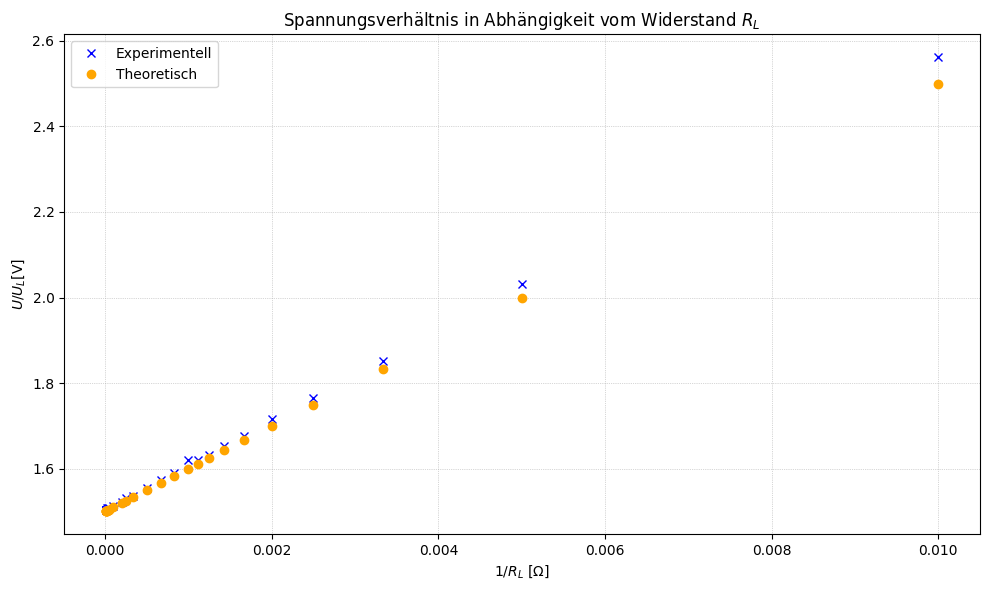

In [ ]:
#| label: fig-spannungsverhältnis
#| fig-cap: Spannungsverhältnis des Spannungsteilers in Abhängigkeit vom Widerstand $R_L$
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# CSV-Datei laden
df = pd.read_csv('Daten/Daten_Aufgabe_2.csv')
df.columns = ['R_L[Ohm]','U[V]','U_L[V]']

# Konstanten definieren
R_1 = 100
R_2 = 200

def U_L(U, R):
    U_L = U * R_2*R/(R_1*R_2 + R_1*R + R_2*R)
    return U_L

df['U_L_theor'] = U_L(df['U[V]'], df['R_L[Ohm]'])
df['U_Verhaelt'] = df['U[V]']/df['U_L[V]']
df['U_theor_Verhaelt'] = df['U[V]']/df['U_L_theor']
df['R_umgekehrt'] = 1/df['R_L[Ohm]']


plt.figure(figsize=(10, 6))
plt.plot(df['R_umgekehrt'], df['U_Verhaelt'],'x', label='Experimentell', color='blue')
plt.plot(df['R_umgekehrt'], df['U_theor_Verhaelt'],'o', label='Theoretisch', color='orange')
plt.xlabel(r'$1/R_L$ [$\Omega$]')
plt.ylabel(r'$U/U_L$[V]')
plt.title(r'Spannungsverhältnis in Abhängigkeit vom Widerstand $R_L$')
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## $R_1$ und $R_1/R_2$ bestimmen

Für das bestimmmen von $R_1$ und $R_1/R_2$ nehmen wir unsere Werte von oben und geben dem ganzen einen linearen fit. Wir können die Formel von oben auch so umstellen, dass wir mithilfe der Fitparameter die beiden gesuchten Werte bestimmen können. Wenn wir die oben hergeleitete Formel nochmal umstellen, bekommen wir:
$$\frac{U}{U_L} = \frac{R_1}{R_L} + \frac{R_1}{R_2} + 1 = a \cdot \frac{1}{R_L} + b$${#eq-normal}
Mit $a = R_1$ und $b = R_1/R_2 + 1$

Theoretischer Fit: Steigung a = 100.000, Achsenabschnitt b = 1.500
Gemessener Fit:     Steigung a = 105.867, Achsenabschnitt b = 1.502


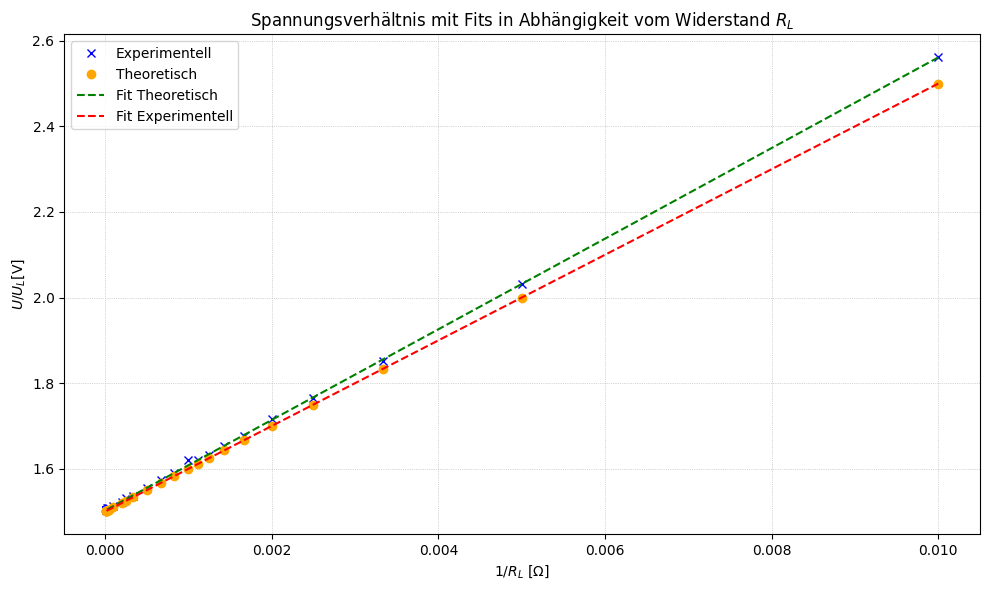

In [ ]:
#| label: fig-spannungsverhältnis-fit
#| fig-cap: Spannungsverhältnis des Spannungsteilers mit Curve-Fit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# CSV-Datei laden
df = pd.read_csv('Daten/Daten_Aufgabe_2.csv')
df.columns = ['R_L[Ohm]','U[V]','U_L[V]']

# Konstanten definieren
R_1 = 100
R_2 = 200

def U_L(U, R):
    U_L = U * R_2*R/(R_1*R_2 + R_1*R + R_2*R)
    return U_L

df['U_L_theor'] = U_L(df['U[V]'], df['R_L[Ohm]'])
df['U_Verhaelt'] = df['U[V]']/df['U_L[V]']
df['U_theor_Verhaelt'] = df['U[V]']/df['U_L_theor']
df['R_umgekehrt'] = 1/df['R_L[Ohm]']

U_L_theor_fit = np.polyfit(df['R_umgekehrt'], df['U_theor_Verhaelt'], 1)
U_L_fit = np.polyfit(df['R_umgekehrt'], df['U_Verhaelt'], 1)

a_theor, b_theor = U_L_theor_fit
a_mess, b_mess = U_L_fit
print(f"Theoretischer Fit: Steigung a = {a_theor:.3f}, Achsenabschnitt b = {b_theor:.3f}")
print(f"Gemessener Fit:     Steigung a = {a_mess:.3f}, Achsenabschnitt b = {b_mess:.3f}")



plt.figure(figsize=(10, 6))
plt.plot(df['R_umgekehrt'], df['U_Verhaelt'],'x', label='Experimentell', color='blue')
plt.plot(df['R_umgekehrt'], df['U_theor_Verhaelt'],'o', label='Theoretisch', color='orange')
plt.plot(df['R_umgekehrt'], np.polyval(U_L_fit, df['R_umgekehrt']), label='Fit Theoretisch', color='green', linestyle='--')
plt.plot(df['R_umgekehrt'], np.polyval(U_L_theor_fit, df['R_umgekehrt']), label='Fit Experimentell', color='red', linestyle='--')
plt.xlabel(r'$1/R_L$ [$\Omega$]')
plt.ylabel(r'$U/U_L$[V]')
plt.title(r'Spannungsverhältnis mit Fits in Abhängigkeit vom Widerstand $R_L$')
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Wir haben nun die Parameter $a$ und $b$ aus unseren Fits, für die Theoretischen Werte sind diese $a = 100$ und $b = 1,5$ und für die Experimentellen Werte sind diese $a = 105,867$ und $b = 1,502$. Für die Theorie sind diese natürlich exakt, da wir $R_1$ und $R_2$ als Werte in unsere Gleichung eingegeben haben und deshalb $a = R_1 = 100 \Omega$ und $b = \frac{R_1}{R_2} + 1 = 1,5 \Rightarrow \frac{R_1}{R_2} = 0,5 = \frac{100}{200}$. Wichtig sind aber die Parameter des Fits für die Experimentell bestimmten Werte. Für diese gilt $R_1 = 105,867 \Omega$ und $\frac{R_1}{R_2} = 0,502$

## Fehlerbetrachtung

Die  Abweichungen sind somit beim Wert $R_1$ 5,8% und beim Verhältnis 0,4%.

# Aufgabe 3
In Aufgabe 3 sollten wir eine Weatstone Brücke aufbauen und die Brüceknspannung messen. Dabei sollen wir die Brückenspannung $U_B$ als Funktiuon von $R_4$ darstellen, wobei $R_4$ ein Dekadenwiederstand war, und den Wiederstand $R_2$ bestimmen. Weiteres galt in der Schaltung $R_1 = R_3$. DIe volle Schaltung ist nach dem Experimentplan in [Abbildung](#fig-experimentierung) zu sehen.
Für den Versuch wurde insgesamt 84 Messungen aufgenommen, wobei der Dekadenwiederstand von 0 $\Omega$ bis 10 $k\Omega$ variiert wurde. Die Messung der Brückenspannung $U_B$ wurde mit einem Multimeter ($\pm 0.5$%$+3$Digits siehe [Fehlertabelle](#fig-fehlertabelle) Multimeter) durchgeführt.
![Experimentieraufbau einer Weatstonschen Brücke für Aufgabe 3](./Bilder/Weartstonebrücke.png){#fig-experimentierung width="70%"}

## Theoretische  Grundlagen
Bei der Weatstone Brücke handelt es sich um eine Schaltung, die aus vier Widerständen besteht, die in Form eines Rechtecks angeordnet sind. Im Gleichgewichtszustand gilt $U_B = 0V$:
$$ \frac{R_2}{R_1} = \frac{R_4}{R_3} $${#eq-gleichgewicht}
Für unsere Weatstonebrücke gilt insbesondere da $R_1 = R_3$, dass im Gleichgewichtzustand $R_2 = R_4$ was sich aus der obigen [Gleichung](#eq-gleichgewicht) ergibt.
Zudem gilt allegmein für Weatstonebrücken immer, das die Brückenspannung $U_B$ wie folgt von den Widerständen abhängt:
$$ U_B = U_2 - U_4 = U_3 - U_1 $${#eq-ub-formel}
Fudem gilt für die Schaltung auch das ohmsche Gesetz.
$$U = R I$${#eq-ohmschesgesetz}

## Theorie und Messwerte
Mit den Formeln die in [Theoretische Grundlagen](#theoretische--grundlagen) gezeigt wurden. Kann nun die Formel zur Berechnung des theoretischen Wertes gezeigt werden. Dabei wird die Brückenspannung $U_B$ als Funktion von $R_4$ dargestellt.
Dafür können wir das [Ohmsche Gesetz]{#eq-ohmschesgesetz} und die allgemeine Formel für $U_B$ nutzen. So kommt man auf eine neue Formel:
$$U_B = R_2 I_2 -R_4I_4$${#eq-ub-vereinfachung}
Da $R_1 = R_3$ gilt, können wir aus dem [ohmschen Gesetz]{#eq-ohmschesgesetz} $I_2$ und $I_4$ wie folgt vereinfacht darstellen:
$$I_2 = \frac{U}{R_2 + R_4}$${#eq-ub-vereinfachung1}
$$I_4 = \frac{U}{R_1 + R_4}$${#eq-ub-vereinfachung2}
Damit kann die Formel für die Brückenspannung $U_B$ weiter vereinfacht werden:
$$U_B = R_2 \frac{U}{R_2 + R_4} - R_4 \frac{U}{R_1 + R_4}$${#eq-ub-vereinfachung3}
Damit lautet die geschlossene Formel für die theoretische Brückenspannung:
$$U_B(R_4) = U \left( \frac{R_2}{R_2 + R_4} - \frac{R_4}{R_1 + R_4} \right)$${#eq-formel-hergeleitet}
FÜr den theoretischen Wert wurden die Wiederstandswerte für $R_4$ von 0 $\Omega$ bis 10000 $\Omega$ genommen in 10 Schritten genommen. Für die Spannung wird der Werte $5V$ genommen

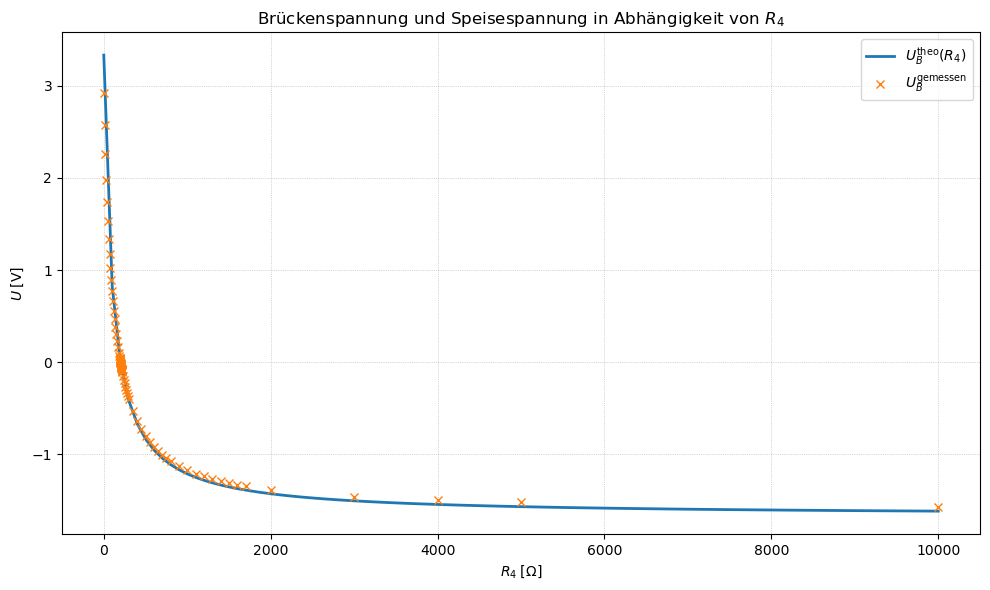

In [ ]:
#| label: fig-reihe-123
#| fig-cap: Brückenspannung und Speisespannung in Abhängigkeit von $R_4$
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Parameter ===
U = 5.0               # Speisespannung [V]
R1 = R3 = 100
R2 = 200            # Widerstandswerte [Ω]

# Theoretische Kurve berechnen
R_4 = np.linspace(0, 10000, 100)  # Widerstandswerte von 0 bis 10kΩ in 100 Schritten
U_B_theo = U * (R2/(R1 + R2) - R_4/(R1 + R_4))

# CSV-Datei mit den Messwerten laden
df = pd.read_csv('Daten/Daten_Aufgabe_3.csv')
df.columns = ['R_4 [Ω]', 'U_B gemessen [V]', 'U gemessen [V]']

# Plot erstellenohm
plt.figure(figsize=(10, 6))

# Theoretische Kurve
plt.plot(R_4, U_B_theo,
         label=r'$U_B^\mathrm{theo}(R_4)$',
         linestyle='-',
         linewidth=2)

# Messkurven
plt.plot(df['R_4 [Ω]'], df['U_B gemessen [V]'],
         marker='x', linestyle='',
         label=r'$U_B^\mathrm{gemessen}$')

#plt.yticks(np.arange(0, 60, 10))  # Y-Achse von -5V bis 5V in Schritten von 1V
#plt.xscale('log')  # Log-Skala (Dann bricht es irgendwie, warum auch immer)
plt.xlabel(r'$R_4\;[\Omega]$')
plt.ylabel(r'$U\;[\mathrm{V}]$')
plt.title('Brückenspannung und Speisespannung in Abhängigkeit von $R_4$')
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


## Auswertung mit nichlinearem Fit

Bei der Auswertung der Messwerte wurde ein nichtlinearer Fit durchgeführt. Dabei wurde die [Formel](#eq-formel-hergeleitet) für die Brückenspannung $U_B(R_4)$ als Funktion von $R_4$ verwendet. Dabei kam man auf einen geschätzten Widerstand für R2 von197.12 $\Omega$ mit einer Standardabweichung von 1.48 $\Omega$ was dem im Experiment genommenen Wert von 200 $\Omega$ sehr nahe kommt wie in [Abbildung @fig-nonlinear-fit].

Geschätzter Widerstand R2: 197.12 Ω
Standardabweichung des geschätzten Widerstands R2: 1.48 Ω


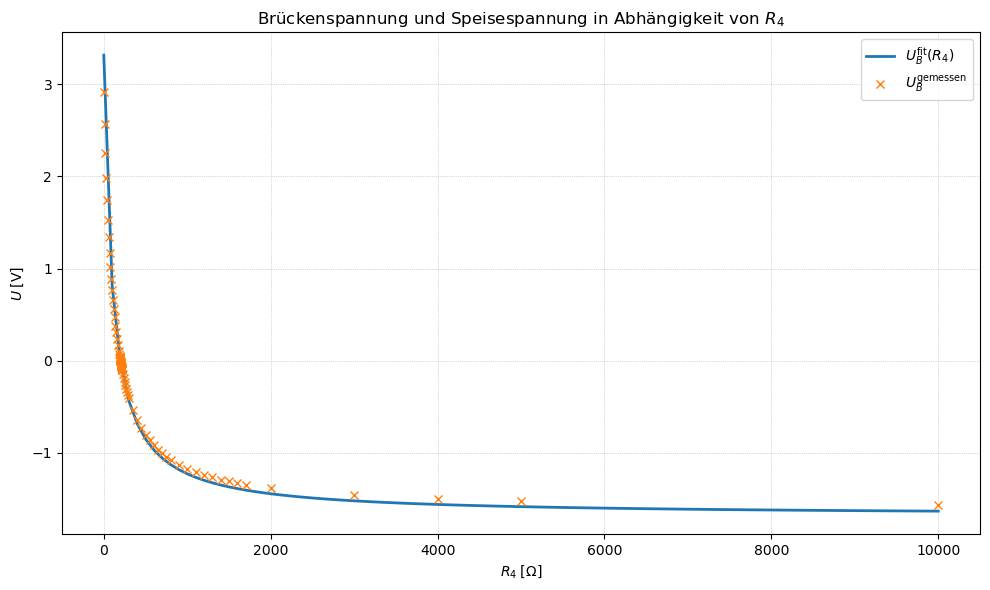

In [ ]:
#| label: fig-nonlinear-fit
#| fig-cap: R über U mit linearem Fit für Reihneschaltung
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# === Parameter ===
U = 5.0               # Speisespannung [V]
R1 = R3 = 100
R_2 = 200            # Widerstandswerte [Ω]

# Theoretische Kurve berechnen
R_4 = np.linspace(0, 10000, 100)  # Widerstandswerte von 0 bis 10kΩ in 100 Schritten
U_B_theo = U * (R_2/(R1 + R_2) - R_4/(R1 + R_4))

def bruecke(R4, R2):
    return U * (R2 / (R1 + R2) - R4 / (R1 + R4))

# CSV-Datei mit den Messwerten laden
df = pd.read_csv('Daten/Daten_Aufgabe_3.csv')
df.columns = ['R_4 [Ω]', 'U_B gemessen [V]', 'U gemessen [V]']

# Curve-Fit
params, covariance = curve_fit(bruecke, df['R_4 [Ω]'], df['U_B gemessen [V]'], p0=[R_2])
# Extrahiere den geschätzten Widerstand R2
R2_estimated = params[0]
#print(f"Geschätzter Widerstand R2: {R2_estimated:.2f} Ω")
sigma_R2 = np.sqrt(np.diag(covariance))[0]
#print(f"Standardabweichung des geschätzten Widerstands R2: {sigma_R2:.2f} Ω")

# Plot erstellen
plt.figure(figsize=(10, 6))

# Theoretische Kurve
plt.plot(R_4, bruecke(R_4, R2_estimated),
         label=r'$U_B^\mathrm{fit}(R_4)$',
         linestyle='-',
         linewidth=2)

# Messkurven
plt.plot(df['R_4 [Ω]'], df['U_B gemessen [V]'],
         marker='x', linestyle='',
         label=r'$U_B^\mathrm{gemessen}$')

#plt.yticks(np.arange(0, 60, 10))  # Y-Achse von -5V bis 5V in Schritten von 1V
#plt.xscale('log')  # Log-Skala (Dann bricht es irgendwie, warum auch immer)
plt.xlabel(r'$R_4\;[\Omega]$')
plt.ylabel(r'$U\;[\mathrm{V}]$')
plt.title('Brückenspannung und Speisespannung in Abhängigkeit von $R_4$')
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


## Feherbetrachtung
Für die Fehlerbtrachtung benutzen wir die [Fehlertabelle]{#fig-fehlertabelle} für das Digitalmultimeter.
Für die theoretischen Werte wurde immer 5V genommen. Die reale Spannungsquelle, fluktuiert aber immer mit dem Strom, so war die echte Spannung immer im bereich 4,99V bis 4,97V. Was eine leichte abweichung der theorie und den Mwssdaten erklähren können.
Zudemm kann man für alle Experimente sagen, dass immer eine ideale Stromkreis angenommen wurde, das heißt es wurde die Wiederstand der Kabel, des Breadboards und des Multimeters wurden nicht beachtet.

# Aufgabe 4

## Aufbau und Messwerte

Bei der vierten Aufgabe, wurden an einem Hochpassfilter die Eingangs- und Ausgangspannung gemessen für folgende Frequenzen:

| Bereich    | Schrittgröße |
| -------- | ------- |
| 100 - 1000 Hz  | 200 Hz    |
| 1 - 10 kHz | 2 kHz     |
| 10 - 100 kHz    | 5 kHz    |
: Messbereiche und Schrittgrößen für die Frequenzen, die gemessen wurden.

Und der Hochpassfilter wurde nach dem folgenden Schaltplan aufgebaut, welcher in der Aufgabe gegeben wurde:
![Schaltplan des Experimentes Hochpassfilter](Bilder/Hochpassfilter.png "Schaltplan Hochpassfilter")

Während unserem Versuch wurden die folgenden Messdaten ermittelt:

| $f$ [Hz]  | $U_A$ [V] | $U_B$ [V] |
|--------|---------|---------|
| 100    | 0.02658 | 1.590   |
| 200    | 0.02658 | 1.590   |
| 400    | 0.02658 | 1.590   |
| 600    | 0.03546 | 1.590   |
| 800    | 0.04446 | 1.590   |
| 1000   | 0.04434 | 1.590   |
| 2000   | 0.07987 | 1.573   |
| 4000   | 0.1332  | 1.520   |
| 6000   | 0.1774  | 1.451   |
| 8000   | 0.228   | 1.372   |
| 10000  | 0.2486  | 1.276   |
| 15000  | 0.3107  | 1.092   |
| 20000  | 0.3374  | 0.935   |
| 25000  | 0.3551  | 0.8214  |
| 30000  | 0.3729  | 0.7428  |
| 35000  | 0.3818  | 0.6816  |
| 40000  | 0.3818  | 0.6292  |
| 45000  | 0.3818  | 0.5940  |
| 50000  | 0.3908  | 0.5680  |
| 55000  | 0.3906  | 0.5418  |
| 60000  | 0.3906  | 0.5243  |
| 65000  | 0.3906  | 0.5068  |
| 70000  | 0.3906  | 0.4986  |
| 75000  | 0.3906  | 0.4806  |
| 80000  | 0.3906  | 0.4719  |
| 85000  | 0.3818  | 0.4631  |
| 90000  | 0.3818  | 0.4546  |
| 95000  | 0.3729  | 0.4456  |
| 100000 | 0.3729  | 0.4282  |
: Ermittelte Messwerte für die Spannung $U_A$ am Ausgang des Hochpassfilters und $U_B$ am Eingang des Hochpassfilters.


## Transferfunktion $U_a/U_e$

Mit diesen Werten können wir das gemessene Verhältnis $\frac{U_a}{U_e}$ in einem Graphen darstellen. Um die theoretischen Werte für das Verhältnis zu berechnen, nutzen wir wieder die Formel für einen Spannungsteiler. Dabei haben wir für $R$ als den Ohmschen Widerstand und $X_c$ als den Blindwiderstand des Kondensators. Für den Blindwiderstand eines Kondensators gilt: $X_c = \frac{1}{j\omega C}$, wobei die Kreisfrequenz $\omega = 2\pi f$ ist, $C$ die Kapazität des Kondensators und j der Imaginäranteil ist.
$$U_a = U_e \cdot \frac{R}{X_c + R} = U_e \cdot \frac{R}{X_c + R}$${#eq-this-is-a-tab-for-equation-numbering}
Diese Formel enthält nicht nur den Betrag der Amplitude sondern auch noch die Phase, weshalb wir um die Amplitude $U_a$ zu bestimmen, den Betrag nutzen:
$$|U_a| = |U_e| \cdot \frac{|R|}{|X_c + R|} \Rightarrow U_a = U_e \cdot \frac{R}{\sqrt{X_c^2 + R^2}}$${#eq-loong-equation}
$$= U_e \cdot \frac{R}{\sqrt{(\frac{1}{2\pi f C})^2 + R^2}} = U_e \cdot \frac{2\pi fCR}{\sqrt{1 + (2\pi fCR)^2}} = U_e \cdot \frac{1}{\sqrt{1 + (\frac{1}{2\pi fCR})^2}}$$


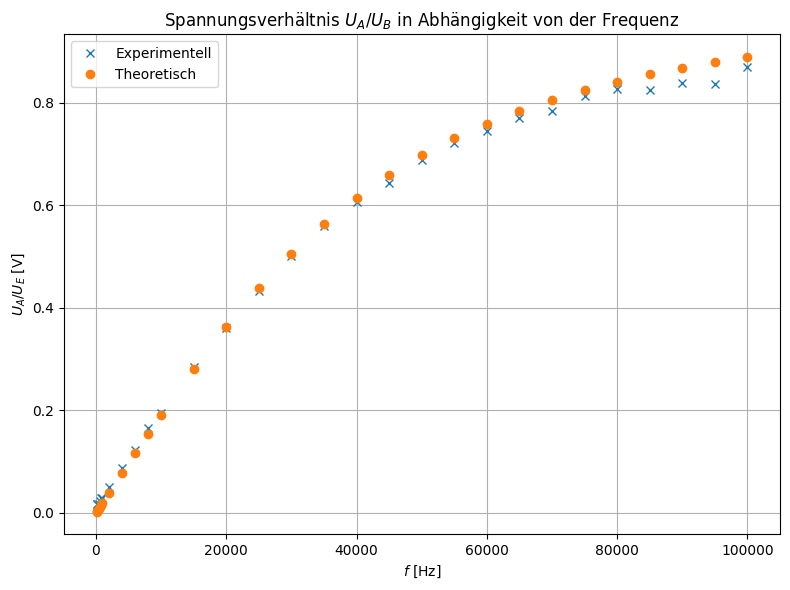

In [ ]:
#| label: fig-spannungsverhältnis-frequenz
#| fig-cap: Spannungsverhältnis des Hochpasses in Abhängigkeit von der Frequenz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# CSV-Datei laden
df = pd.read_csv('Daten/Daten_Aufgabe_4.csv')
df.columns = ['f [Hz]', 'U_A[V]', 'U_B[V]']

def U_A_E_theor(R, C, f):
    U_A_E_theor = 1/(np.sqrt(1 + (1/(2*np.pi*R*C*f))**2))
    return U_A_E_theor

df['U_A_U_B'] = df['U_A[V]'] / df['U_B[V]']
df['U_A_E_theor'] = U_A_E_theor(200, 1.55e-8, df['f [Hz]'])


# Plot
plt.figure(figsize=(8, 6))
#plt.plot(df['f [Hz]'], df['U_A[V]'], 'o-', label='U_A[V]')
#plt.plot(df['f [Hz]'], df['U_B[V]'], 'x--', label='U_B[V]')
plt.plot(df['f [Hz]'], df['U_A_U_B'], 'x', label='Experimentell')
plt.plot(df['f [Hz]'], df['U_A_E_theor'], 'o', label='Theoretisch')
plt.xlabel(r'$f$ [Hz]')
plt.ylabel(r'$U_A/U_E$ [V]')
plt.title(r'Spannungsverhältnis $U_A/U_B$ in Abhängigkeit von der Frequenz')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Im zweiten Teil der Aufgabe bestimmen wir die Grenzfrequenz $f_c$. Bei dieser Grenzfrequenz gilt für das Eingangs- und Ausgangssignal: $U_a = U_e/\sqrt{2}$. In der Theorie kann man den Wert mithilfe $R$ und $C$ berechnen, mit der Formel:
$$f_c = \frac{1}{2\pi RC}$${#eq-54321}
Bei unserem Versuch hatten wir einen Widerstand mit $R = 200 \Omega$ und einen Kondensator mit $C = 15,5 nF$. Somit ist die berechnete Grenzfrequenz:
$$f_c = \frac{1}{2\pi \cdot 200\Omega \cdot 15,5 \cdot 10^{-9} nF} = 51,340 kHz$${#eq-1777}
Der Experimentelle Wert wird bestimmt, indem eine Fit-funktion für die Daten gefunden wird und die Frequenz ausgegeben wird, bei der das Verhältnis $1/\sqrt{2}$ entspricht.

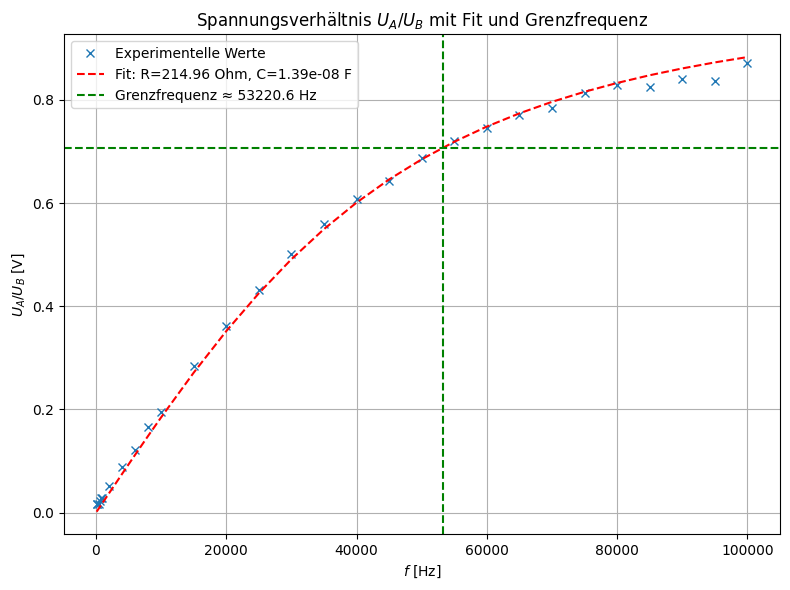

In [ ]:
#| label: fig-grenzfrequenz
#| fig-cap: Spannungsverhältnis mit Curve-Fit und Grenzfrequenz des Hochpasses
from scipy.optimize import curve_fit, fsolve
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# CSV-Datei laden
df = pd.read_csv('Daten/Daten_Aufgabe_4.csv')
df.columns = ['f [Hz]', 'U_A[V]', 'U_B[V]']

def U_A_E_theor(R, C, f):
    U_A_E_theor = 1/(np.sqrt(1 + (1/(2*np.pi*R*C*f))**2))
    return U_A_E_theor

df['U_A_U_B'] = df['U_A[V]'] / df['U_B[V]']
df['U_A_E_theor'] = U_A_E_theor(200, 1.55e-8, df['f [Hz]'])

popt, pcov = curve_fit(U_A_E_theor, df['f [Hz]'], df['U_A_U_B'], p0=[200, 1.55e-8])
R_fit, C_fit = popt

# Grenzfrequenz berechnen (U_A/U_B = 1/sqrt(2))
def find_cutoff_freq(f):
    return U_A_E_theor(f, R_fit, C_fit) - 1/np.sqrt(2)


f_cutoff = fsolve(find_cutoff_freq, x0=1000)[0]  # Startwert 1000 Hz

# Plot
plt.figure(figsize=(8, 6))
plt.plot(df['f [Hz]'], df['U_A_U_B'], 'x', label='Experimentelle Werte')
plt.plot(df['f [Hz]'], U_A_E_theor(R_fit, C_fit, df['f [Hz]']), 'r--', label='Fit: R=%.2f Ohm, C=%.2e F' % (R_fit, C_fit))
plt.axhline(1/np.sqrt(2), color='green', linestyle='--')
plt.axvline(f_cutoff, color='green', linestyle='--', label=f'Grenzfrequenz ≈ {f_cutoff:.1f} Hz')
plt.xlabel(r'$f$ [Hz]')
plt.ylabel(r'$U_A/U_B$ [V]')
plt.title(r'Spannungsverhältnis $U_A/U_B$ mit Fit und Grenzfrequenz')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Fehlerbetrachtung

Die Abweichungen bei der Grenzfrequenz betragen 3,66%, welche durch die Fitfunktion entstehen. Der Grenzfrequenz Wert wird bestimmt, indem sich der Wert der Fitfunktion angeschaut wird, bei dem das Verhältnis stimmt. Da die Experimentellen Werte aber nicht komplett mit den theoretischen übereinstimmen, ist auch der Fit nicht genau und der beste der gefunden wurde, stimmt mit den theoretischen Werten für $R=214 \Omega$ und $C= 13,9 nF$ überein. Da dies nicht mit den genutzten Werten übereinstimmt, kann auch die Grenzfrequenz nicht übereinstimmen.

# Fehlertabelle des Digitalmultimeters
![Fehlertabelle des Digitalmultimeters entnommen der Expermentierbeschreibung von Moodel](./Bilder/Fehlermultimeter.png){#fig-fehlertabelle width="60%"}


# Quellen
Alle Abbildungen der Schaltungen sowie die [Fehlertablle](#fig-fehlertabelle) des Digitalmultimeters wurden der Experiment Beschreibung auf Moodel entnommen